# Match Sample IDs Bulk

Notebook to figure out which samples are from the same person. 
It uses the `match_sample_id()` function from `match_sample_ids.py` and makes a heatmap plot of the results.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from match_sample_ids import match_sample_id

In [2]:
cwd = os.getcwd()

In [ ]:
res, df = match_sample_id(
    cwd + "/bcftools/all/bcftools_all_samples.vcf.gz", 
    cwd + "/bcftools/all/bcftools_all_samples.vcf.gz"
    )

Shape for Geno Prob in VCF1: (260772, 66, 3)
Shape for Geno Prob in VCF2: (260772, 66, 3)
n_variants in VCF1, VCF2 and matched: 260772, 260772, 260772
aligned donors:
['230509/2018' '230509/2023' '230509/2094' '230509/2126' '230509/2129'
 '230509/2186' '230509/2202' '230509/2209' '230509/2240' '230509/2309'
 '230509/2313' '230509/2401' '230509/2407' '230509/2444' '230509/2483'
 '230509/2526' '230626/2216' '230626/2221' '230626/2230' '230626/2238'
 '230626/2246' '230626/2249' '230626/2268' '230626/2278' '230626/2296'
 '230626/2364' '230626/2408' '230626/2416' '230626/2423' '230626/2430'
 '230626/2455' '230626/2460' '230626/2466' '230626/2477' '230626/2514'
 '230414/2018' '230414/2126' '230414/2202' '230414/2221' '230414/2240'
 '230414/2278' '230414/2364' '230414/2407' '230414/2416' '230414/2477'
 '230414/2023' '230414/2129' '230414/2209' '230414/2238' '230414/2249'
 '230414/2313' '230414/2401' '230414/2408' '230414/2460' '230414/2483'
 '230414/2526' '230418/2094' '230418/2186' '230418/2

In [ ]:
# Save the dataframe with the matched sample IDs
pair_df = df.copy()
# Create a dataframe with the heatmap values
df = pd.DataFrame(
    res["matched_GPb_diff"],
    columns=res["matched_donors2"],
    index=res["matched_donors1"],
)
# Clean up the column and index names to remove the sample id prefix
# (only if the sample ids are unique in the columns and rows)
# df.columns = df.columns.str.replace(r"\d{6}/", "", regex=True)
# df.index = df.index.str.replace(r"\d{6}/", "", regex=True)

In [18]:
df

,230509/2018,230509/2023,230509/2094,230509/2126,230509/2129,230509/2186,230509/2202,230509/2209,230509/2240,230509/2309,...,230418/2094,230418/2186,230418/2216,230418/2230,230418/2246,230418/2309,230418/2423,230418/2455,230418/2466,230418/2514
230509/2018,0.000000,0.188029,0.185827,0.185460,0.212138,0.193924,0.189188,0.198073,0.189874,0.202209,...,0.294989,0.296874,0.302659,0.327176,0.312930,0.310145,0.307460,0.307496,0.314617,0.322458
230509/2023,0.188029,0.000000,0.187775,0.191540,0.212805,0.195206,0.190763,0.200105,0.190842,0.203475,...,0.295021,0.296400,0.303033,0.325607,0.311888,0.307363,0.309290,0.306828,0.312284,0.321416
230509/2094,0.185827,0.187775,0.000000,0.190716,0.210787,0.192581,0.186217,0.199673,0.190199,0.202460,...,0.198989,0.295270,0.304011,0.327445,0.312190,0.310275,0.310198,0.306090,0.313729,0.319493
230509/2126,0.185460,0.191540,0.190716,0.000000,0.212008,0.191650,0.190986,0.198631,0.189767,0.200612,...,0.294409,0.292066,0.300012,0.324908,0.308671,0.310786,0.307012,0.306156,0.312706,0.318793
230509/2129,0.212138,0.212805,0.210787,0.212008,0.000000,0.213447,0.214466,0.219161,0.211622,0.213927,...,0.296235,0.296511,0.302164,0.316596,0.306729,0.308000,0.306971,0.298129,0.308382,0.313881
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
230418/2309,0.310145,0.307363,0.310275,0.310786,0.308000,0.311928,0.309423,0.306606,0.309611,0.302979,...,0.175399,0.182007,0.175144,0.171905,0.172955,0.000000,0.164127,0.178826,0.173212,0.195814
230418/2423,0.307460,0.309290,0.310198,0.307012,0.306971,0.307016,0.309867,0.303424,0.308146,0.293833,...,0.177292,0.173839,0.168833,0.159865,0.170121,0.164127,0.000000,0.169557,0.176745,0.194080
230418/2455,0.307496,0.306828,0.306090,0.306156,0.298129,0.302605,0.306297,0.309924,0.307269,0.293482,...,0.172364,0.171910,0.176029,0.174070,0.167829,0.178826,0.169557,0.000000,0.174231,0.187236
230418/2466,0.314617,0.312284,0.313729,0.312706,0.308382,0.310982,0.313358,0.321543,0.315098,0.304673,...,0.175498,0.177269,0.185282,0.171810,0.158474,0.173212,0.176745,0.174231,0.000000,0.196994


In [ ]:
# For a certain heatmap plots, we need to bring in a few extra rows
# extra_df = pd.read_csv(cwd + "/../data/bcftools/heatmap_raw_bulk_v_diss_bulk_filter4.csv", index_col=0)
# extra_df = extra_df.loc[[2018, 2023, 2094, 2126, 2129]]

# df = pd.concat([df, extra_df])

In [ ]:
# Sample order for the heatmap plot when all bulk and dissociated bulk samples are included in both rows and columns
sample_order_df = pd.DataFrame({"samples": sorted(set(df.columns) | set(df.index))})
# Sort by sample type and sample id
# Extract sample id from the sample names
sample_order_df["sample_id"] = sample_order_df["samples"].str[-4:]
sample_order_df["date"] = sample_order_df["samples"].str[:4]
# Assign sample type based on the date
sample_order_df.loc[sample_order_df["date"] == "2304", "sample_type"] = "diss_bulk"
sample_order_df.loc[sample_order_df["date"] != "2304", "sample_type"] = "bulk"
# Sort by sample type and then by sample id
sample_order_df = sample_order_df.sort_values(by=["sample_type", "sample_id"])

sample_order_lst = list(sample_order_df["samples"])
# Apply the sample order to the columns and the index of the dataframe
sorted_df = df[sample_order_lst]
sorted_df = sorted_df.loc[sample_order_lst]

In [20]:
# Sample order for the heatmap plot when dissociated bulk samples are only in the columns and bulk samples are only in the rows
# df.index = df.index.astype(str)
# sorted_df = df[sorted(df.columns)]
# sorted_df = sorted_df.loc[sorted(sorted_df.index)]

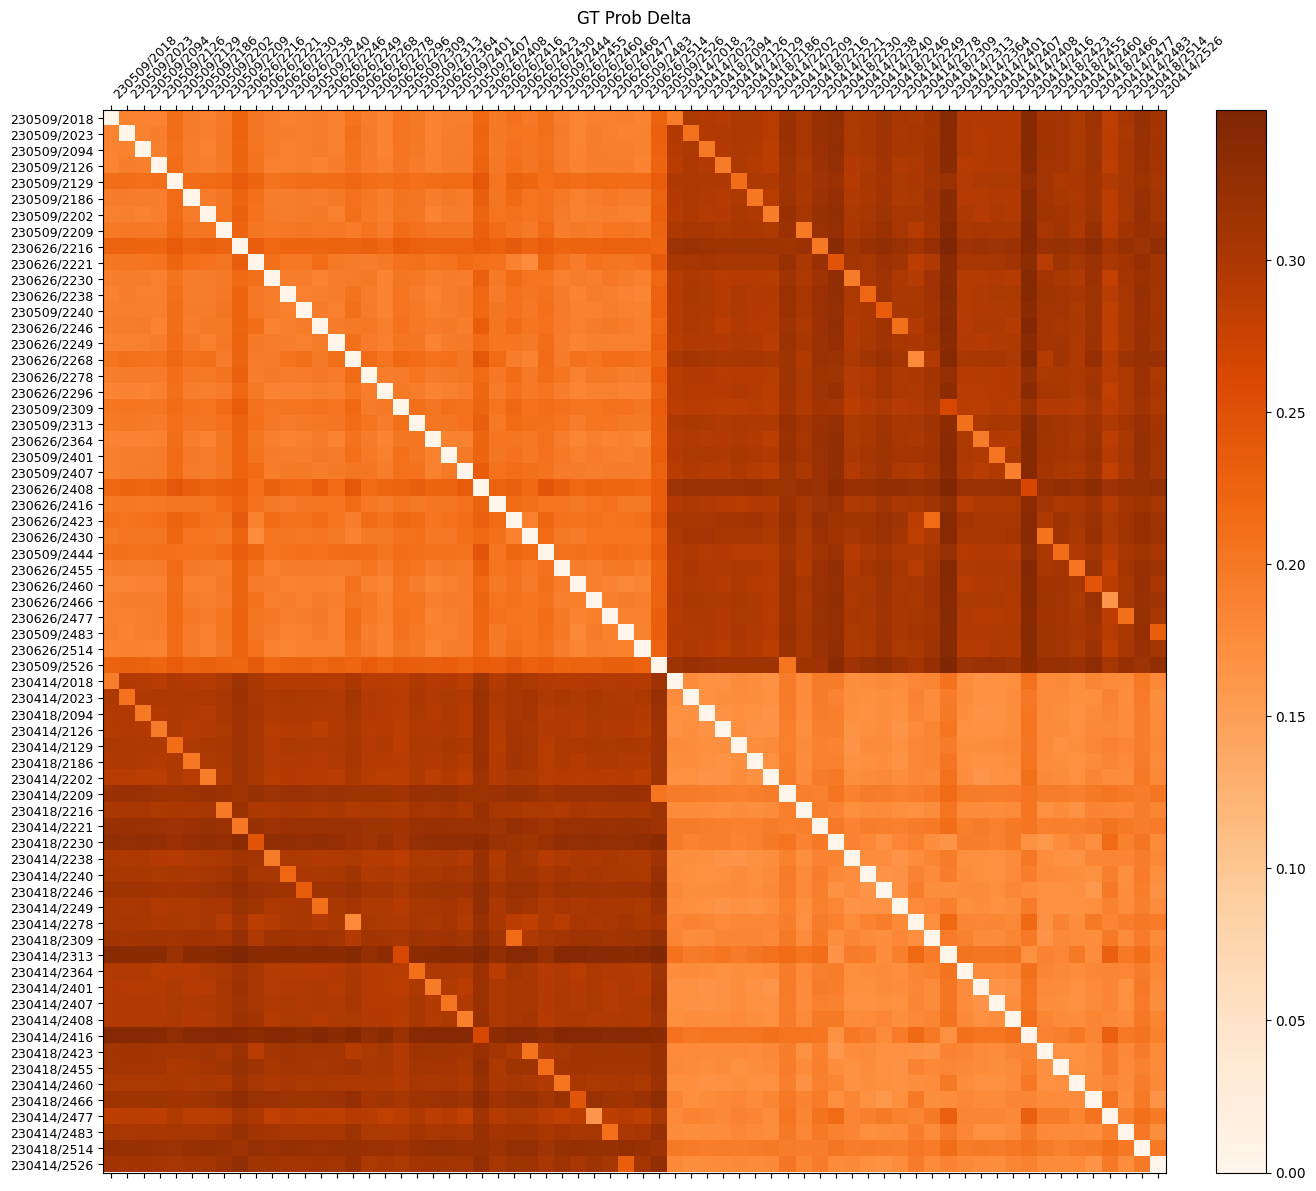

In [21]:
fig, ax = plt.subplots(figsize=(15, 15))
heatmap = ax.matshow(sorted_df, cmap="Oranges")

# # Numbers in grid
# for (i, j), z in np.ndenumerate(sorted_df):
#     ax.text(j, i, "{:.2f}".format(z), ha="center", va="center", fontdict={"fontsize": 6})

ax.set_xticks(np.arange(len(df.columns)))
ax.set_yticks(np.arange(len(df)))
ax.set_xticklabels(sorted_df.columns, rotation=45, ha="left", fontdict={"fontsize": 9})
ax.set_yticklabels(sorted_df.index, fontdict={"fontsize": 9})
ax.xaxis.set_label_position("top")
# ax.set_xlabel("Dissociated bulk ref")
# ax.set_ylabel("Bulk ref")
ax.set_title("GT Prob Delta")

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size=0.5, pad=0.5)
cbar = fig.colorbar(heatmap, cax=cax)

plt.show()

In [ ]:
filename = cwd + "/../figures/diss_vs_bulk_ref/GT_delta_filter_dp900_w2507_all_samples"
fig.savefig(filename + ".pdf", bbox_inches="tight")
fig.savefig(filename + ".png", bbox_inches="tight")